In [ ]:
library(spacexr)
library(Matrix)

mat <- readMM("data/sc_count_matrix_MB.mtx")

In [83]:
counts <- as.data.frame(as.matrix(mat))

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.7 GiB”


In [ ]:
meta_data <- read.table('data/sc_label_louvine_MB.txt',sep='\t',header = TRUE,row.names = 1)
meta_data$barcode=rownames(meta_data)

In [ ]:
meta_data$cell_type <- as.character(meta_data$cell_type)
rownames(counts)=meta_data$barcode
meta_data <- subset(meta_data, cell_type != "25")
gene_df = read.table('data/sc_gene_MB.txt',sep='\t',header = TRUE,row.names = 1)
colnames(counts)=rownames(gene_df)
counts1=counts[meta_data$barcode,]
counts=counts1

In [ ]:
cell_types <- meta_data$cell_type; names(cell_types) <- meta_data$barcode # create cell_types named list
cell_types <- as.factor(cell_types) # convert to factor data type
nUMI <- rowSums(counts); names(nUMI) <- meta_data$barcode # create nUMI named list
reference <- Reference(t(counts), cell_types, nUMI)
STdata_counts = read.table('data/st_count_matrix_MB.txt',sep='\t',row.names = 1,header = TRUE)
location = read.table('results/ST_location_simulate.txt',sep='\t',header=TRUE,row.names = 1)

[1] 32285  2695


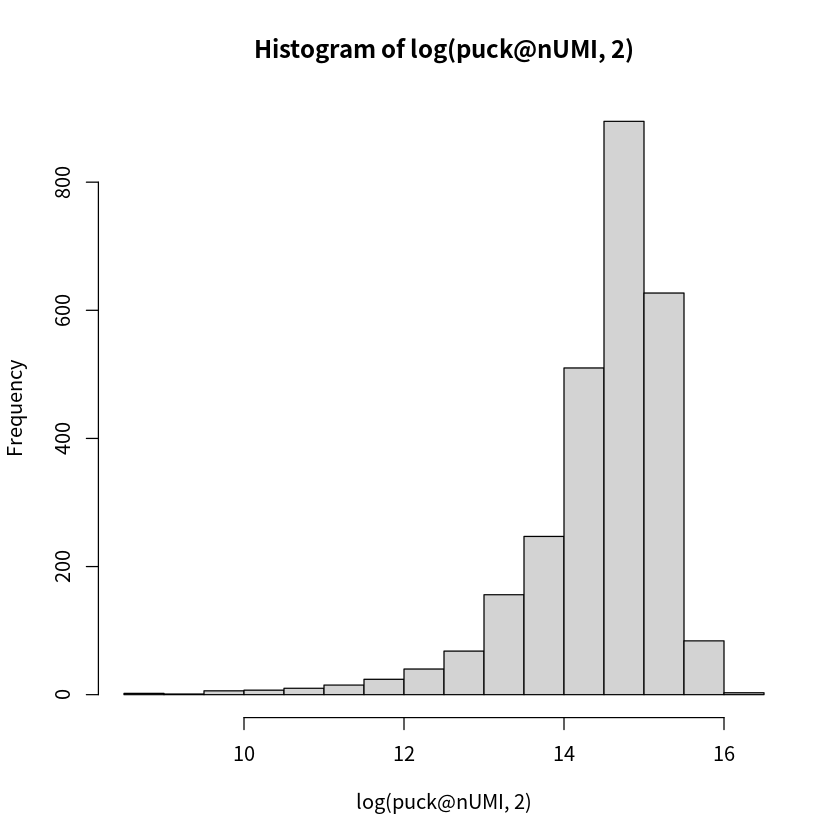

In [ ]:
coords <- location[,c(1,2)]
colnames(coords)=c('xcoord','ycoord')
counts <- STdata_counts
colnames(counts)=rownames(coords)
nUMI <- colSums(counts) # In this case, total counts per pixel is nUMI
### Create SpatialRNA object
puck <- SpatialRNA(coords, counts, nUMI)
## Examine SpatialRNA object (optional)
print(dim(puck@counts)) # observe Digital Gene Expression matrix
hist(log(puck@nUMI,2)) # histogram of log_2 nUMI

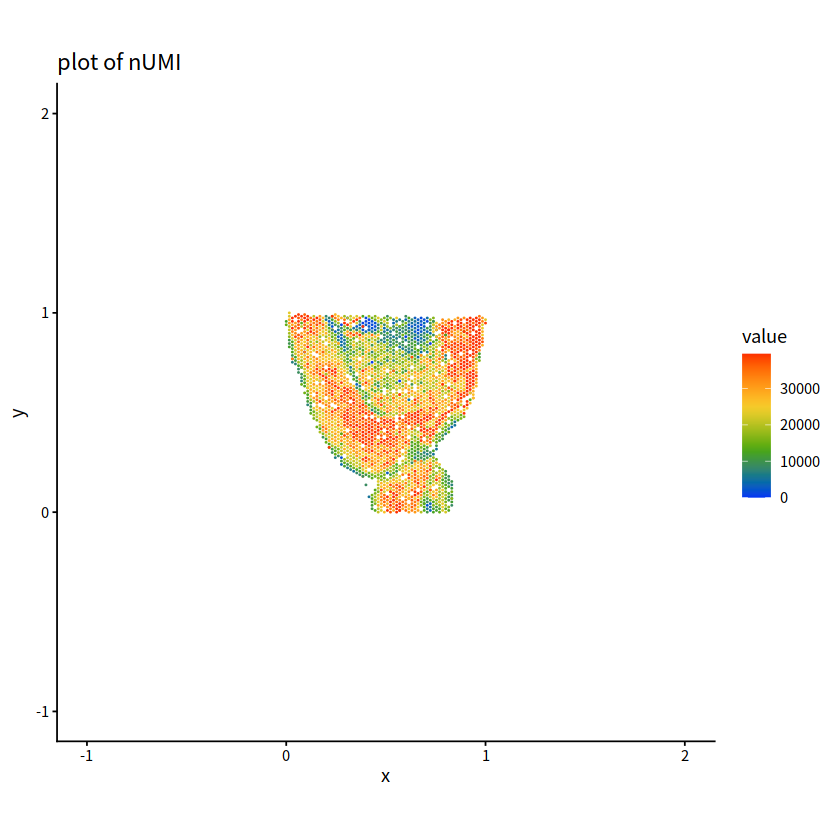

In [98]:

barcodes <- colnames(puck@counts) # pixels to be used (a list of barcode names). 

# This list can be restricted if you want to crop the puck e.g. 
# puck <- restrict_puck(puck, barcodes) provides a basic plot of the nUMI of each pixel
# on the plot:
plot_puck_continuous(puck, barcodes, puck@nUMI, ylimit = c(0,round(quantile(puck@nUMI,0.9))), 
                     title ='plot of nUMI') 

In [99]:
myRCTD <- create.RCTD(puck, reference, max_cores = 1)

Begin: process_cell_type_info

process_cell_type_info: number of cells in reference: 11607

process_cell_type_info: number of genes in reference: 19059




   0    1   10   11   12   13   14   15   16   17   18   19    2   20   21   22 
1867 1358  463  377  361  300  228  227  161  140  123  122  881  112  106   88 
  23   24    3    4    5    6    7    8    9 
  56   31  849  844  769  593  578  508  465 


End: process_cell_type_info

create.RCTD: getting regression differentially expressed genes: 

get_de_genes: 0 found DE genes: 443

get_de_genes: 1 found DE genes: 330

get_de_genes: 10 found DE genes: 158

get_de_genes: 11 found DE genes: 254

get_de_genes: 12 found DE genes: 117

get_de_genes: 13 found DE genes: 358

get_de_genes: 14 found DE genes: 253

get_de_genes: 15 found DE genes: 274

get_de_genes: 16 found DE genes: 481

get_de_genes: 17 found DE genes: 203

get_de_genes: 18 found DE genes: 282

get_de_genes: 19 found DE genes: 274

get_de_genes: 2 found DE genes: 69

get_de_genes: 20 found DE genes: 316

get_de_genes: 21 found DE genes: 246

get_de_genes: 22 found DE genes: 219

get_de_genes: 23 found DE genes: 408

get_de_genes: 24 found DE genes: 278

get_de_genes: 3 found DE genes: 401

get_de_genes: 4 found DE genes: 93

get_de_genes: 5 found DE genes: 142

get_de_genes: 6 found DE genes: 149

get_de_genes: 7 found DE genes: 260

get_de_genes: 8 found DE genes: 164

get_

In [100]:
myRCTD <- run.RCTD(myRCTD, doublet_mode = 'doublet')

fitBulk: decomposing bulk

chooseSigma: using initial Q_mat with sigma =  1

Likelihood value: 5159286.61892757

Sigma value:  0.84

Likelihood value: 5041089.50437713

Sigma value:  0.69

Likelihood value: 4941989.52772369

Sigma value:  0.61

Likelihood value: 4896699.04240792

Sigma value:  0.53

Likelihood value: 4858892.47009507

Sigma value:  0.45

Likelihood value: 4830736.87663403

Sigma value:  0.37

Likelihood value: 4814779.35398452

Sigma value:  0.33

Likelihood value: 4812234.9127381

Sigma value:  0.33



[1] "gather_results: finished 1000"
[1] "gather_results: finished 2000"


In [ ]:
results <- myRCTD@results
full_matrix <- as.matrix(results$weights)
write.table(full_matrix, file = "results/RCTD_weights.txt", sep = "\t", quote = FALSE)